# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

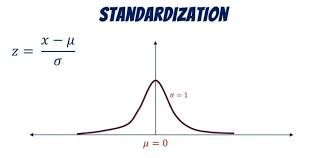


Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

Open the file in read mode

In [ ]:
raw = np.genfromtxt('co2 Emission Africa.csv', delimiter=',', dtype=str, encoding='utf-8')
header = raw[0]
data = raw[1:]

print('Data shape:', data.shape)
print('Header:', header)

**Explanation** The file loads as **1,134 rows × 20 columns**: 54 countries × 21 years (2000–2020). There are 5 sub-regions: Eastern, Middle, Northern, Southern and Western Africa. The header shows three kinds of column:
- **Identifiers:** Country, Sub-Region, Code, Year.
- **Socio-economic indicators:** population, GDP per capita, area.
- **CO₂ emissions** broken down by sector.

np.genfromtxt with dtype=str works here because no field contains a quoted comma.

Check for missing values

In [ ]:
missing = ['', 'NA', 'N/A']
for j, name in enumerate(header):
    n_missing = np.isin(data[:, j], missing).sum()
    if n_missing > 0:
        print(f'{name} has {n_missing} missing values')

In [ ]:
#find the numeric columns
def numeric_column(column):
    values = column[~np.isin(column, missing)]
    try:
        values.astype(float)
        return True
    except ValueError:
        return False

numeric_idx = [j for j in range(len(header)) if numeric_column(data[:, j])]
non_numeric = [header[j] for j in range(len(header)) if j not in numeric_idx]

print('Numeric columns:', len(numeric_idx))
print('Non-numeric (kept as labels):', non_numeric)

**Explanation:** The function tries to convert each column's non-missing values to float. **17 columns are numeric** and **3 are non-numeric**:
- Country has 54 nmes.
- Sub-Region` has 5 categories.
- Code is the 3-etter ISO country code.

These are identified here and handled in the encoding step below.

In [ ]:
missing_frac = np.isin(data, missing).mean(axis=0)
MAX_MISSING = 0.5

keep_idx = [j for j in numeric_idx if missing_frac[j] <= MAX_MISSING]
dropped = [(header[j], round(missing_frac[j] * 100, 1)) for j in numeric_idx if j not in keep_idx]

print('Dropped for too many missing values (name, % missing):', dropped)

**Explanation:** A feature that is more than 50% missing cannot be imputed reliably, because most of its values would be invented. **Fugitive Emissions** (70.9% missing) is therefore dropped as a column. Every other numeric column is below 6% missing, so those columns are kept and imputed.

In [ ]:
# Year is a time index, not a measurement.
# The three totals are sums of other columns, so they would duplicate information in PCA.
exclude = ['Year',
            'Total CO2 Emission including LUCF (Mt)',
            'Total CO2 Emission excluding LUCF (Mt)',
            'Energy (Mt)']

feature_idx = [j for j in keep_idx if header[j] not in exclude]
feature_names = [str(header[j]) for j in feature_idx]

def to_float(v):
    return np.nan if v in missing else float(v)

X = np.array([[to_float(v) for v in row] for row in data[:, feature_idx]])

countries = data[:, 0]
subregions = data[:, 1]
years = data[:, 3]

print('Features used:', len(feature_names))
print(feature_names)
print('Feature matrix shape:', X.shape)
print('NaN per feature:', np.isnan(X).sum(axis=0))
print('Rows with any NaN:', np.isnan(X).any(axis=1).sum())

**Explanation:** Besides Fugitive Emissions, four more numeric columns are excluded:
- Year is a time index, not a characteristic of a country.
- Energy is the sum of the energy sectors (transport, electricity, manufacturing, buildings, other fuel).
- Total CO2 excluding LUCF is Energy plus Industrial Processes.
- Total CO2 including LUCF additionally adds Land-Use Change.

Keeping the totals would count the same emissions twice, and PCA would treat that artificial correlation as real structure. That leaves **12 features**: 4 socio-economic (population, 2 × GDP per capita, area) and 8 emission sectors. There are still **121 NaNs spread over 101 rows**.

#### Handling the remaining missing values
The missing values are not all the same kind, so they are handled in three ways:

| Case | Rows affected | Treatment | Why |
|---|---|---|---|
| **South Sudan, 2000–2011** | 12 rows | **Drop the rows** | The country only became independent in 2011. These rows have no emissions data at all, so any value we filled in would be invented |
| A country has *some* values for a feature | e.g. Botswana's Industrial Processes 2000–2008, Somalia's GDP 2000–2012 | **The country's own median** for that feature | A country's economy and emissions change slowly, so its own median is far more realistic than a continental average. The median is robust to outlier years |
| A country has *no* values for a feature | Eritrea's GDP PPP, Somalia's Industrial Processes | **The median of its sub-region in the same year** | Neighbouring economies in the same year are the closest available comparison |

Dropping every row with a NaN (the simplest option) would throw away 101 rows (9% of the data). It would also delete **every year** for Eritrea and Somalia, removing two countries from the analysis.

In [ ]:
not_yet_independent = (countries == 'South Sudan') & (years.astype(int) < 2012)

X_clean = X[~not_yet_independent].copy()
countries_clean = countries[~not_yet_independent]
subregions_clean = subregions[~not_yet_independent]
years_clean = years[~not_yet_independent].astype(int)

print('Rows dropped (South Sudan before independence):', not_yet_independent.sum())
print('Before:', X.shape, ' After:', X_clean.shape)
print('NaN still to impute:', np.isnan(X_clean).sum())

In [ ]:
X_original = X_clean.copy()  # look up medians in the original values only, never in imputed ones
filled_country, filled_region = 0, 0
for j in range(X_clean.shape[1]):
    for i in np.where(np.isnan(X_original[:, j]))[0]:
        own = X_original[countries_clean == countries_clean[i], j]
        if (~np.isnan(own)).any():
            X_clean[i, j] = np.nanmedian(own)
            filled_country += 1
        else:
            peers = (subregions_clean == subregions_clean[i]) & (years_clean == years_clean[i])
            X_clean[i, j] = np.nanmedian(X_original[peers, j])
            filled_region += 1

print('Filled with country median         :', filled_country)
print('Filled with sub-region/year median :', filled_region)
print('NaN remaining                      :', np.isnan(X_clean).sum())
print('Final shape                        :', X_clean.shape)

**Explanation:** All 121 remaining NaNs are resolved and the dataset has **1,122 complete rows**.
- **79 values** were filled with the country's own median. For example, Somalia's GDP for 2000–2012 is filled from its 2013–2020 values.
- **42 values** had no data for that country at all (Eritrea's GDP PPP and Somalia's Industrial Processes, 21 years each). These were filled with the sub-region's median for the same year.

The medians are always taken from the **original** values, never from previously imputed ones. This way every Eritrea year gets its own regional estimate instead of copying the first year's value.

#### Encoding the non-numeric columns
- **Sub-Region** (5 categories) is **one-hot encoded** into 5 binary columns. We do not add these dummies to the PCA features. Binary 0/1 columns do not have the continuous variance structure PCA assumes, and they would dominate a component on their own. Instead, the encoded region is used to **colour the plots and test whether PCA recovers regional groupings** from the numeric data alone.
- **Country** (54 categories) and **Code** (the ISO code, which duplicates Country) are identifiers. One-hot encoding them would add 54 sparse columns that describe *which* country a row is, not *how* it behaves, so they are kept only as labels.

In [ ]:
REGIONS = list(np.unique(subregions_clean))
region_onehot = (subregions_clean[:, None] == np.array(REGIONS)[None, :]).astype(int)

print('One-hot columns:', REGIONS)
print('Encoded shape  :', region_onehot.shape)
print('First 3 rows   :', countries_clean[:1], '\n', region_onehot[:3])
print('Rows per region:', dict(zip(REGIONS, region_onehot.sum(axis=0).tolist())))
print('Each row belongs to exactly one region:', np.all(region_onehot.sum(axis=1) == 1))

#### Log transform of the skewed features
Emissions, population and GDP are extremely right-skewed. Nigeria has around 200 million people and São Tomé around 200,000, and South Africa emits hundreds of Mt of CO₂ while small states emit less than 1 Mt. Left as-is, a handful of giant countries would dominate the covariance matrix. We therefore apply a **signed log**, $\text{sign}(x)\cdot\log(1+|x|)$. This is the usual log1p for positive values, but it also works for **Land-Use Change and Forestry**, which is *negative* when forests absorb more CO₂ than land use releases.

In [ ]:
def skewness(A):
    d = A - A.mean(axis=0)
    return (d ** 3).mean(axis=0) / (d ** 2).mean(axis=0) ** 1.5

X_log = np.sign(X_clean) * np.log1p(np.abs(X_clean))

print(f"{'Feature':<36}{'skew raw':>10}{'skew log':>10}")
for name, s1, s2 in zip(feature_names, skewness(X_clean), skewness(X_log)):
    print(f'{name:<36}{s1:>10.2f}{s2:>10.2f}')

**Explanation:**
- **Before the transform**, skewness is between 1.3 and 7.1. Land-Use Change is the worst (7.1), because DR Congo's deforestation emissions dwarf everyone else's.
- **After the signed log**, population, GDP, area and land-use become close to symmetric (between −1.1 and +0.5).
- **The emission sectors improve from 3–6 to about 1.4–2.7.** Some skew remains because many small countries report **exactly 0** in some sectors (e.g. 439 zeros in Other Fuel Combustion), and a transform cannot spread out a pile of identical zeros.

The data is now measured in orders of magnitude, so PCA compares countries by relative size instead of being dominated by South Africa, Egypt and Nigeria.

#### Standardization using $Z = \dfrac{X - \mu}{\sigma}$

In [ ]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
mean = np.mean(X_log, axis=0)
std = np.std(X_log, axis=0)
standardized_data = (X_log - mean) / std
standardized_data[:5]  # Display the first few rows of standardized data

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [ ]:
# Step 3: Calculate the Covariance Matrix
n = standardized_data.shape[0]  # Number of samples
cov_matrix = (standardized_data.T @ standardized_data) / (n-1)  # Calculate covariance matrix # Calculate covariance matrix
cov_matrix

In [ ]:
print('Shape:', cov_matrix.shape)
print('Symmetric:', np.allclose(cov_matrix, cov_matrix.T))
print('Diagonal (should be ~1):', np.round(np.diag(cov_matrix), 3))
print('Matches np.cov:', np.allclose(cov_matrix, np.cov(standardized_data, rowvar=False)))

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

We compute the covariance matrix for three reasons:

It measures how every pair of features varies together. The very high covariances (e.g. manufacturing–building 0.92, GDP USD–PPP 0.95) show that the 12 features contain a lot of redundant information, and that redundancy is exactly what PCA removes.
PCA is defined on this matrix: its eigenvectors are the directions of maximum variance (the principal components) and its eigenvalues are the amount of variance along each one.
Because the data is standardized, it equals the correlation matrix, so population (in millions) and emissions (in Mt) contribute on an equal footing.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [ ]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix) # Perform eigendecomposition
eigenvalues, eigenvectors

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [ ]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]    # Sort eigenvectors accordingly

# An eigenvector's sign is arbitrary (v and -v are both valid); flip so the largest weight is positive
signs = np.sign(sorted_eigenvectors[np.abs(sorted_eigenvectors).argmax(axis=0), np.arange(sorted_eigenvectors.shape[1])])
sorted_eigenvectors = sorted_eigenvectors * signs
sorted_eigenvectors

**Explanation:** The eigenvalues are now in **descending order**, from 6.94 down to 0.039, and the check confirms it. Column *i* of sorted_eigenvectors is principal component *i*, so the first column is the direction of greatest variance. Each eigenvector's sign is arbitrary, since −v is just as valid as v. We flip each one so that its largest weight is positive, which makes the plots and interpretation reproducible without changing any variance.

#### Explained variance and dynamic selection of components (Task 2)
The explained variance of component *i* is $\lambda_i / \sum_j \lambda_j$. We keep the **smallest number of components whose cumulative explained variance reaches 90%**. That number is calculated from the data, not typed in by hand.

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [ ]:
# Step 6: Project Data onto Principal Components
num_components = selected_k  # Decide on the number of principal components to keep (chosen from the 90% threshold)
reduced_data = standardized_data @ sorted_eigenvectors[:, :num_components]  # Project data onto the principal components

reduced_data[:5]

**Explanation:** Projecting multiplies the standardized data (1,122 × 12) by the first 4 sorted eigenvectors (12 × 4), giving each country-year 4 principal-component scores. The rows shown are **Algeria 2000–2004**:
- **PC1 ≈ 4.6 to 5.2:** far above average. Algeria's oil and gas economy makes it one of Africa's largest emitters, and the score rises each year as its emissions grow.
- **PC2 ≈ 0 to −0.7:** slightly on the wealthier side, with little land-use pressure.

This matches reality.

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [ ]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

The data went from **1,122 × 12 to 1,122 × 4**. That is a **67% reduction** in the number of features with **no rows lost**, while keeping 91.5% of the variance. The checks confirm the projection is correct:
- The variance of each PC exactly equals its eigenvalue, so PC1 has the most variance and each later one has less.
- Every PC has mean 0, so the data is centred.
- The PCs are perfectly uncorrelated, so the redundancy in the original 12 features is gone.

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

In [ ]:
# Step 8: Visualize Before and After PCA
region_colors = dict(zip(REGIONS, ['#4C78A8', '#54A24B', '#E45756', '#B279A2', '#F58518']))
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# Plot original data (first two features for simplicity)
for reg in REGIONS:
    m = subregions_clean == reg
    axes[0].scatter(standardized_data[m, 0], standardized_data[m, 1], s=14, alpha=0.6, c=region_colors[reg], label=reg)
axes[0].set_xlabel(f'{feature_names[0]} (standardized log)')
axes[0].set_ylabel(f'{feature_names[1]} (standardized log)')
axes[0].set_title(f'Before PCA: original feature space ({standardized_data.shape[0]} points)')

# Plot reduced data after PCA
for reg in REGIONS:
    m = subregions_clean == reg
    axes[1].scatter(reduced_data[m, 0], reduced_data[m, 1], s=14, alpha=0.6, c=region_colors[reg], label=reg)
axes[1].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}% of variance)')
axes[1].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}% of variance)')
axes[1].set_title(f'After PCA: principal component space ({reduced_data.shape[0]} points)')

for ax in axes:
    ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)
    ax.legend(title='Sub-Region (one-hot encoded)', fontsize=8)
plt.tight_layout(); plt.show()

print('Same number of points before and after:', standardized_data.shape[0] == reduced_data.shape[0])
print(f'Var(PC1) = {reduced_data[:, 0].var(ddof=1):.3f}  >  Var(PC2) = {reduced_data[:, 1].var(ddof=1):.3f}')
print(f'PC space centred at: ({reduced_data[:, 0].mean():.1e}, {reduced_data[:, 1].mean():.1e})')

latest = years_clean == years_clean.max()
names_latest = countries_clean[latest]
for pc in (0, 1):
    order = np.argsort(reduced_data[latest, pc])
    print(f'\nPC{pc+1} lowest  ({years_clean.max()}):', ', '.join(names_latest[order[:5]]))
    print(f'PC{pc+1} highest ({years_clean.max()}):', ', '.join(names_latest[order[::-1][:5]]))

print('\nSub-region centroids in PC space (PC1, PC2):')
for reg in REGIONS:
    c = reduced_data[subregions_clean == reg, :2].mean(axis=0)
    print(f'  {reg:<17}{c[0]:>7.2f}{c[1]:>7.2f}')


**Explanation:**
- Both plots show the same **1,122 points**. The PC space is centred at (0, 0), and Var(PC1) = 6.94 is greater than Var(PC2) = 2.67, as the rubric requires.
- In the before plot, each country appears as a **diagonal streak**, because its population and GDP both grow over the 21 years. The regions overlap almost completely.
- In the after plot, the **Northern African** emitters move far to the right, and the other regions spread out along PC2.
- The printed 2020 rankings show what the axes mean:
  - **PC1, low to high:** low-emission small economies (São Tomé, Comoros, Burundi, Guinea-Bissau) → the big emitters (South Africa, Egypt, Algeria, Nigeria, Morocco).
  - **PC2, low to high:** small, richer-per-capita island states (Seychelles, Mauritius, São Tomé, Cabo Verde) → large, populous, lower-income countries with heavy land-use emissions (DR Congo, Mozambique, Ethiopia, Tanzania).
- The sub-region centroids confirm that **PCA recovered regional structure from the numbers alone**, even though Sub-Region was never a PCA input:
  - Northern Africa sits at (4.58, −0.56).
  - Southern Africa sits at (1.21, −1.07).
  - Eastern, Middle and Western Africa cluster together at about (−0.8, +0.2).

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?


1. Before PCA, Population vs GDP per capita shows overlapping diagonal streaks (each country growing over 21 years), and the five sub-regions are mixed together. After PCA, the same 1,122 points are rotated onto centred, uncorrelated axes. PC1 (57.8%, the widest spread) orders countries by their economic-activity emissions footprint, from São Tomé and Burundi up to Egypt and South Africa. PC2 (22.2%) separates large, populous, lower-income countries with land-use emissions (DR Congo, Ethiopia) from small, wealthier island states (Seychelles, Mauritius). Northern and Southern Africa now separate clearly from the rest, a structure that was invisible before.

2. Why we selected this number of principal components, and the tradeoffs We let the data choose: k is the smallest number of components whose cumulative explained variance reaches 90%, which gives 4 of 12 PCs (91.50%). The tradeoff is simplicity versus information. Keeping only PC1 and PC2 (the Kaiser rule) would be easy to interpret and plot, but it keeps 80% of the variance and drops the land-use/income pattern in PC3 (7.8%). Keeping 4 cuts the features by two-thirds while retaining over 90% of the information. The cost is that PC3 and PC4 are harder to interpret, and the 8 dropped PCs (8.5%) are given up entirely.

3. PC1 merges all 7 energy and industry sectors into one "economic activity" score. We can no longer tell whether a country's emissions come mainly from electricity (South Africa's coal) or from transport, even though that decides which climate policy fits. PC2 blends population pressure with low income and deforestation, so a populous but low-deforestation country can look like a heavy land-clearer. The dropped PCs (8.5%) hold country-specific quirks, such as unusually high bunker fuels in port and island economies, and year-to-year shocks. The PCs also have no units, so absolute tonnes of CO₂ and per-person income cannot be read back directly.

## Task 3: Optimizing PCA for Performance and Large Datasets
The step-by-step PCA above is packaged into reusable functions and benchmarked against a naive version.

| Technique | Why it is faster or scales better |
|---|---|
| **Vectorized covariance** ZᵀZ/(n−1) | One optimized matrix multiply instead of O(n·p²) Python loops |
| **np.linalg.eigh** instead of eig | Uses the fact that the covariance matrix is symmetric: faster, always real, numerically stable |
| **np.searchsorted** on cumulative variance | Finds k without a Python loop |
| **float32** option | Halves memory and memory bandwidth, with negligible precision loss for PCA |
| **Chunked (streaming) covariance** | Adds up Σx and Σxxᵀ one block of rows at a time, so the full dataset never has to be in RAM (works with np.memmap for files larger than memory) |.

In [ ]:
def pca_naive(X, threshold=0.90):
    n, p = X.shape
    Z = (X - X.mean(axis=0)) / X.std(axis=0)
    C = np.zeros((p, p))
    for i in range(p):
        for j in range(p):
            s = 0.0
            for k in range(n):
                s += Z[k, i] * Z[k, j]
            C[i, j] = s / (n - 1)
    vals, vecs = np.linalg.eig(C)
    vals, vecs = vals.real, vecs.real
    order = np.argsort(vals)[::-1]
    vals, vecs = vals[order], vecs[:, order]
    k = int(np.argmax(np.cumsum(vals) / vals.sum() >= threshold) + 1)
    return Z @ vecs[:, :k], vals, k

In [ ]:
def pca_fast(X, threshold=0.90, dtype=np.float64):
    X = np.asarray(X, dtype=dtype)
    Z = (X - X.mean(axis=0)) / X.std(axis=0)
    C = (Z.T @ Z) / (Z.shape[0] - 1)
    vals, vecs = np.linalg.eigh(C)
    vals, vecs = vals[::-1], vecs[:, ::-1]
    k = int(np.searchsorted(np.cumsum(vals) / vals.sum(), threshold) + 1)
    return Z @ vecs[:, :k], vals, k

In [ ]:
def pca_chunked(X, threshold=0.90, chunk=50_000):
    n, p = X.shape
    s, ss = np.zeros(p), np.zeros((p, p))
    for start in range(0, n, chunk):
        b = np.asarray(X[start:start + chunk], dtype=np.float64)
        s += b.sum(axis=0)
        ss += b.T @ b
    mu = s / n
    scatter = ss - n * np.outer(mu, mu)
    sd = np.sqrt(np.diag(scatter) / n)
    C = scatter / (n - 1) / np.outer(sd, sd)
    vals, vecs = np.linalg.eigh(C)
    vals, vecs = vals[::-1], vecs[:, ::-1]
    k = int(np.searchsorted(np.cumsum(vals) / vals.sum(), threshold) + 1)
    out = np.empty((n, k))
    for start in range(0, n, chunk):
        out[start:start + chunk] = ((X[start:start + chunk] - mu) / sd) @ vecs[:, :k]
    return out, vals, k

In [ ]:
def best_time(fn, *args, repeats=3):
    best = np.inf
    for _ in range(repeats):
        t0 = time.perf_counter(); fn(*args); best = min(best, time.perf_counter() - t0)
    return best

In [ ]:
_, v_naive, k_naive = pca_naive(X_log)
_, v_fast, k_fast = pca_fast(X_log)
_, v_chunk, k_chunk = pca_chunked(X_log, 0.90, 200)
print('Correctness check on the CO2 data:')
print(f'  fast    == step-by-step eigenvalues: {np.allclose(v_fast, sorted_eigenvalues)} | k = {k_fast}')
print(f'  naive   == fast eigenvalues        : {np.allclose(v_naive, v_fast)} | k = {k_naive}')
print(f'  chunked == fast eigenvalues        : {np.allclose(v_chunk, v_fast)} | k = {k_chunk}')

In [ ]:
**Explanation:**
- **Correctness:** all three implementations give the same eigenvalues and the same k = 4 as the step-by-step PCA, so the optimizations do not change the result.
- **Speed:** the vectorized version is **about 180–300× faster** than the naive loop version (the left-hand plot labels the exact speed-up at each size, and it varies from run to run). The naive version was stopped at 20,000 rows, where it already takes about a second. Extrapolated to 1 million rows it would take about a minute, while the optimized version handles **1 million rows × 12 features in under 0.5 s**.
- **Scaling:** runtime grows linearly with the number of rows (a straight line in the right-hand plot). The expensive eigendecomposition only ever runs on the small 12 × 12 covariance matrix, whatever the number of rows.
- **Memory:** float32 halves memory (96 MB → 48 MB) and is about 25–40% faster. The chunked version never holds more than one block of rows at a time, so it can process data larger than RAM, for example streamed from disk with np.memmap.

Github: https://github.com/Abigail-Salem-Tendo/Team_6_PCA.git